In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [6]:
months = {
    "Jan":1, "feb":2, "Mar":3, "Apr":4,
    "May":5, "Jun":6, "Jul":7, "Aug":8,
    "Sep":9, "Oct":10, "Nov":11, "Dec":12
}

df['month'] = df['month'].map(months)

In [7]:
X = df[['year', 'month']]
y = df['passengers']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
     test_size=0.2,
     random_state=42
)

In [9]:
X_test

,year,month
117,1958,10.0
19,1950,8.0
82,1955,11.0
97,1957,NaN
56,1953,9.0
12,1950,1.0
132,1960,1.0
65,1954,6.0
66,1954,7.0
18,1950,7.0


In [10]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = sns.load_dataset("flights")

# First 5 Rows
print(df.head())

# Last 5 Rows
print(df.tail())

# Dataset Shape
print("Shape:", df.shape)

# Column Names
print(df.columns)

# Data Types
print(df.dtypes)

# Dataset Info
print(df.info())

# Null Values
print(df.isnull().sum())

# Statistical Summary
print(df.describe())

# Unique Months
print(df["month"].unique())

# Unique Years
print(df["year"].unique())

# Display Dataset
print(df)

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
     year month  passengers
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432
Shape: (144, 3)
Index(['year', 'month', 'passengers'], dtype='object')
year             int64
month         category
passengers       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None
year          0
month         0
passengers    0
dtype: int64
              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.29861

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# Load Dataset
df = sns.load_dataset("flights")

# Encode Month
le = LabelEncoder()
df["month"] = le.fit_transform(df["month"])

# Features and Target
X = df[["year", "month"]]
y = df["passengers"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("R2 Score:", r2_score(y_test, y_pred))

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

R2 Score: 0.8411230149448436
Coefficient: [32.90322536 -1.19034799]
Intercept: -64020.8317835495


In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Absolute error"] = abs(comparison["Actual"] - comparison["Predicted"])

print(comparison)

    Actual   Predicted  Absolute error
0      359  391.779996       32.779996
1      170  139.267325       30.732675
2      237  294.260667       57.260667
3      301  367.209206       66.209206
4      237  226.073521       10.926479
5      115  135.696281       20.696281
6      417  464.728534       47.728534
7      264  264.928486        0.928486
8      302  266.118834       35.881166
9      170  134.505933       35.494067
10     235  239.167349        4.167349
11     364  299.022059       64.977941
12     271  327.163893       56.163893
13     391  465.918882       74.918882
14     355  361.257466        6.257466
15     234  262.547790       28.547790
16     163  173.360898       10.360898
17     229  260.167094       31.167094
18     472  429.444613       42.555387
19     233  301.402755       68.402755
20     118  105.173751       12.826249
21     337  401.302779       64.302779
22     362  395.351040       33.351040
23     435  396.541388       38.458612
24     272  237.977001   

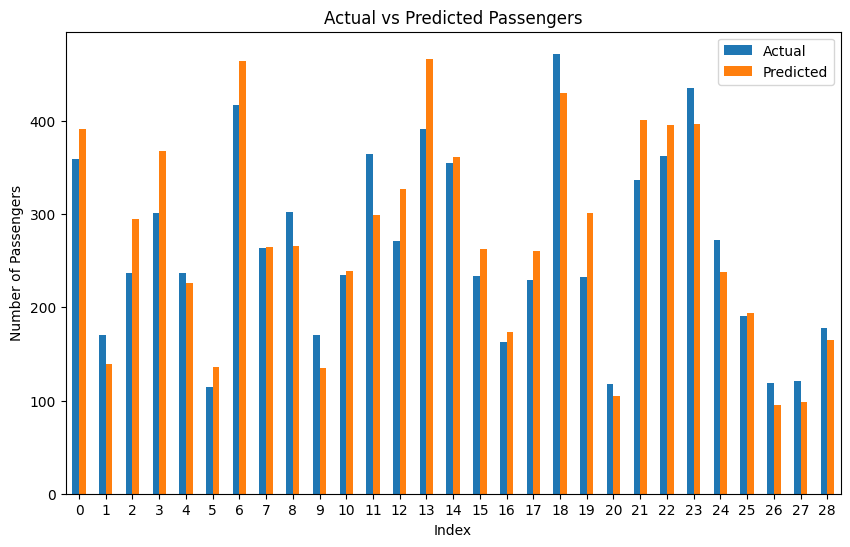

In [16]:

comparison.plot(kind="bar", figsize=(10, 6))
plt.title("Actual vs Predicted Passengers")
plt.xlabel("Index")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()